<a href="https://colab.research.google.com/github/bndto-s0clsta/Spline_cUbico_fiee/blob/main/SplineCubico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Frecuencia (Hz)    Impedancia (Ohm)
--------------------------------------
       100             152.3
       120             149.1
       145             146.8
       170             144.9
       200             142.0
       235             139.5
       270             137.9
       310             136.1
       355             134.8
       405             133.6
       460             132.7
       520             131.9
       585             131.4
       655             131.1
       730             130.9
       810             131.0
       895             131.3
       985             131.9
      1080             132.7
      1180             133.8
      1290             135.2
      1410             136.9
      1540             138.9
      1680             141.1
      1830             143.5
      1990             146.1
      2160             149.0
      2340             152.2
      2530             155.6
      2730             159.2


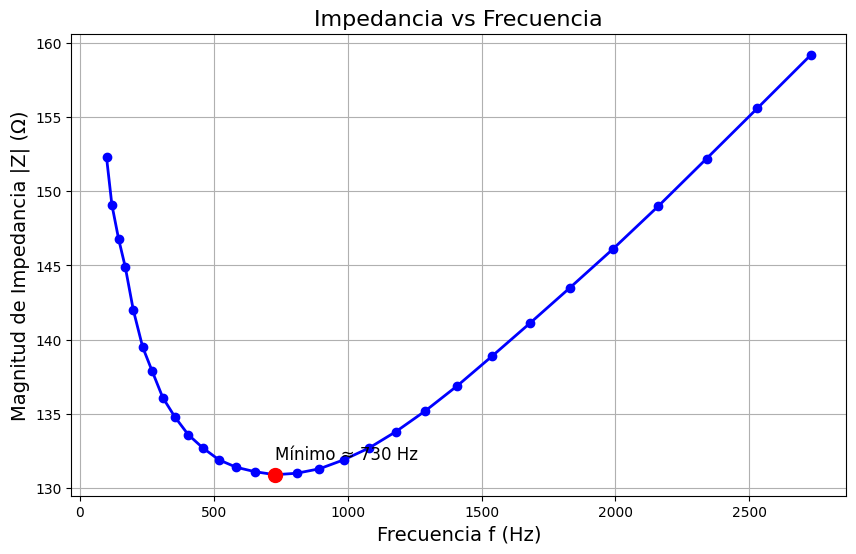

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATOS DEL EXAMEN
# =========================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,2530,2730
])

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,136.1,134.8,133.6,
    132.7,131.9,131.4,131.1,130.9,131.0,131.3,131.9,132.7,133.8,
    135.2,136.9,138.9,141.1,143.5,146.1,149.0,152.2,155.6,159.2
])

# =========================
# MOSTRAR DATOS ORDENADOS
# =========================

print(" Frecuencia (Hz)    Impedancia (Ohm)")
print("--------------------------------------")

for i in range(len(f)):
    print(f"{f[i]:>10}          {Z[i]:>8}")

# =========================
# GRAFICAR
# =========================

plt.figure(figsize=(10,6))

plt.plot(f, Z, 'bo-', linewidth=2, markersize=6)

plt.title('Impedancia vs Frecuencia', fontsize=16)
plt.xlabel('Frecuencia f (Hz)', fontsize=14)
plt.ylabel('Magnitud de Impedancia |Z| (Ω)', fontsize=14)

plt.grid(True)

# Marcar mínimo aproximado
indice_min = np.argmin(Z)

plt.plot(f[indice_min], Z[indice_min], 'ro', markersize=10)

plt.text(
    f[indice_min],
    Z[indice_min] + 1,
    f'Mínimo ≈ {f[indice_min]} Hz',
    fontsize=12
)

plt.show()

In [ ]:
import numpy as np
import sympy as sp

# =====================================================
# DATOS
# =====================================================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,
    2530,2730
], dtype=float)

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,
    136.1,134.8,133.6,132.7,131.9,131.4,131.1,
    130.9,131.0,131.3,131.9,132.7,133.8,135.2,
    136.9,138.9,141.1,143.5,146.1,149.0,152.2,
    155.6,159.2
])

# =====================================================
# INTERPOLACIÓN POLINÓMICA
# MÉTODO MATRICIAL
# =====================================================

grado = 5

coef = np.polyfit(f, Z, grado)

P_matricial = np.poly1d(coef)

# =====================================================
# INTERPOLACIÓN DE LAGRANGE
# =====================================================

x = sp.Symbol('x')

# Usamos pocos puntos para evitar Runge

f_lag = f[:6]
Z_lag = Z[:6]

n = len(f_lag)

P_lagrange = 0

for i in range(n):

    Li = 1

    for j in range(n):

        if i != j:

            Li *= (x - f_lag[j]) / (f_lag[i] - f_lag[j])

    P_lagrange += Z_lag[i] * Li

# Expandir polinomio

P_lagrange_expandido = sp.expand(P_lagrange)

# =====================================================
# MOSTRAR POLINOMIOS
# =====================================================

print("\n==============================")
print("POLINOMIO MÉTODO MATRICIAL")
print("==============================\n")

print(P_matricial)

print("\n==============================")
print("POLINOMIO DE LAGRANGE")
print("==============================\n")

print(P_lagrange_expandido)


POLINOMIO MÉTODO MATRICIAL

            5             4             3             2
-4.572e-15 x + 3.744e-11 x - 1.179e-07 x + 0.0001816 x - 0.1257 x + 161.6

POLINOMIO DE LAGRANGE

4.90790297553549e-10*x**5 - 2.77541835513005e-7*x**4 + 4.29917880920005e-5*x**3 + 0.00161919331473825*x**2 - 0.956505550586371*x + 211.61311439499


In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

# =====================================================
# DATOS
# =====================================================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,
    2530,2730
], dtype=float)

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,
    136.1,134.8,133.6,132.7,131.9,131.4,131.1,
    130.9,131.0,131.3,131.9,132.7,133.8,135.2,
    136.9,138.9,141.1,143.5,146.1,149.0,152.2,
    155.6,159.2
])

# =====================================================
# POLINOMIO SELECCIONADO
# =====================================================

grado = 5

# Construcción del polinomio
coef = np.polyfit(f, Z, grado)

P = np.poly1d(coef)

# =====================================================
# INTERPOLACIÓN EN 1000 Hz
# =====================================================

f_eval = 1000

Z_interp = P(f_eval)

print("\n==============================")
print("VALOR INTERPOLADO")
print("==============================")

print(f"|Z|(1000 Hz) = {Z_interp:.4f} Ohm")

# =====================================================
# VALIDACIÓN LEAVE-ONE-OUT (LOO)
# =====================================================

loo = LeaveOneOut()

errores = []

print("\n==============================")
print("VALIDACIÓN LOO")
print("==============================\n")

contador = 1

for train_index, test_index in loo.split(f):

    # Datos entrenamiento
    x_train = f[train_index]
    y_train = Z[train_index]

    # Punto eliminado
    x_test = f[test_index]
    y_test = Z[test_index]

    # Nuevo polinomio sin ese punto
    coef_loo = np.polyfit(
        x_train,
        y_train,
        grado
    )

    P_loo = np.poly1d(coef_loo)

    # Predicción
    y_pred = P_loo(x_test)

    # Error relativo porcentual
    error_relativo = abs(
        (y_test - y_pred) / y_test
    ) * 100

    errores.append(error_relativo[0])

# =====================================================
# ERROR PROMEDIO
# =====================================================

error_promedio = np.mean(errores)

print(f"Error relativo promedio = {error_promedio:.4f}%")


VALOR INTERPOLADO
|Z|(1000 Hz) = 132.3572 Ohm

VALIDACIÓN LOO

Error relativo promedio = 0.5160%



DERIVADA d|Z|/df

f =  100.0 Hz   d|Z|/df =  -0.174903
f =  120.0 Hz   d|Z|/df =  -0.130193
f =  145.0 Hz   d|Z|/df =  -0.071501
f =  170.0 Hz   d|Z|/df =  -0.087801
f =  200.0 Hz   d|Z|/df =  -0.091474
f =  235.0 Hz   d|Z|/df =  -0.053799
f =  270.0 Hz   d|Z|/df =  -0.044758
f =  310.0 Hz   d|Z|/df =  -0.038429
f =  355.0 Hz   d|Z|/df =  -0.024866
f =  405.0 Hz   d|Z|/df =  -0.020607
f =  460.0 Hz   d|Z|/df =  -0.014387
f =  520.0 Hz   d|Z|/df =  -0.010910
f =  585.0 Hz   d|Z|/df =  -0.005366
f =  655.0 Hz   d|Z|/df =  -0.003671
f =  730.0 Hz   d|Z|/df =  -0.000818
f =  810.0 Hz   d|Z|/df =   0.002512
f =  895.0 Hz   d|Z|/df =   0.005080
f =  985.0 Hz   d|Z|/df =   0.007633
f = 1080.0 Hz   d|Z|/df =   0.009633
f = 1180.0 Hz   d|Z|/df =   0.012013
f = 1290.0 Hz   d|Z|/df =   0.013431
f = 1410.0 Hz   d|Z|/df =   0.014881
f = 1540.0 Hz   d|Z|/df =   0.015641
f = 1680.0 Hz   d|Z|/df =   0.015852
f = 1830.0 Hz   d|Z|/df =   0.016080
f = 1990.0 Hz   d|Z|/df =   0.016578
f = 2160.0 Hz   d|Z

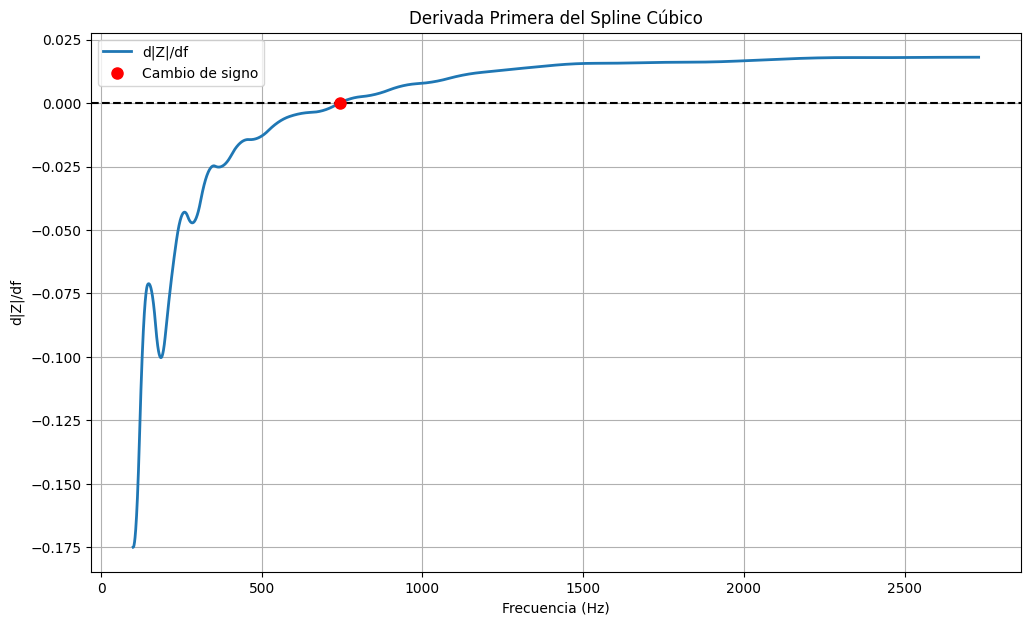

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# =====================================================
# DATOS
# =====================================================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,
    2530,2730
], dtype=float)

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,
    136.1,134.8,133.6,132.7,131.9,131.4,131.1,
    130.9,131.0,131.3,131.9,132.7,133.8,135.2,
    136.9,138.9,141.1,143.5,146.1,149.0,152.2,
    155.6,159.2
])

# =====================================================
# SPLINE CÚBICO NATURAL
# =====================================================

spline = CubicSpline(
    f,
    Z,
    bc_type='natural'
)

# =====================================================
# DERIVADA PRIMERA DEL SPLINE
# =====================================================

spline_derivada = spline.derivative()

# =====================================================
# EVALUACIÓN EN LOS PUNTOS
# =====================================================

dZ_df = spline_derivada(f)

# =====================================================
# MOSTRAR DERIVADAS
# =====================================================

print("\n======================================")
print("DERIVADA d|Z|/df")
print("======================================\n")

for i in range(len(f)):

    print(
        f"f = {f[i]:>6.1f} Hz   "
        f"d|Z|/df = {dZ_df[i]:>10.6f}"
    )

# =====================================================
# ENCONTRAR MÍNIMO
# =====================================================

# Malla fina para mayor precisión
f_fina = np.linspace(min(f), max(f), 5000)

derivada_fina = spline_derivada(f_fina)

# Punto donde cambia de negativo a positivo
indice_min = np.where(
    np.diff(np.sign(derivada_fina))
)[0][0]

frecuencia_min = f_fina[indice_min]

print("\n======================================")
print("UBICACIÓN DEL MÍNIMO")
print("======================================\n")

print(f"Frecuencia aproximada del mínimo:")
print(f"f ≈ {frecuencia_min:.4f} Hz")

# =====================================================
# GRÁFICA DE LA DERIVADA
# =====================================================

plt.figure(figsize=(12,7))

plt.plot(
    f_fina,
    derivada_fina,
    linewidth=2,
    label='d|Z|/df'
)

# Línea horizontal en cero
plt.axhline(
    0,
    color='black',
    linestyle='--'
)

# Punto del mínimo
plt.plot(
    frecuencia_min,
    0,
    'ro',
    markersize=8,
    label='Cambio de signo'
)

plt.title('Derivada Primera del Spline Cúbico')

plt.xlabel('Frecuencia (Hz)')

plt.ylabel('d|Z|/df')

plt.grid(True)

plt.legend()

plt.show()

In [9]:
import numpy as np
from scipy.interpolate import CubicSpline

# =====================================================
# DATOS
# =====================================================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,
    2530,2730
], dtype=float)

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,
    136.1,134.8,133.6,132.7,131.9,131.4,131.1,
    130.9,131.0,131.3,131.9,132.7,133.8,135.2,
    136.9,138.9,141.1,143.5,146.1,149.0,152.2,
    155.6,159.2
])

# =====================================================
# SPLINE CÚBICO NATURAL
# =====================================================

spline = CubicSpline(
    f,
    Z,
    bc_type='natural'
)

# =====================================================
# PRIMERA DERIVADA
# =====================================================

primera_derivada = spline.derivative()

# =====================================================
# SEGUNDA DERIVADA
# =====================================================

segunda_derivada = spline.derivative(2)

# =====================================================
# ENCONTRAR EL MÍNIMO
# =====================================================

# Malla fina para mayor precisión
f_fina = np.linspace(min(f), max(f), 5000)

# Evaluar primera derivada
d1 = primera_derivada(f_fina)

# Encontrar cambio de signo
indice_min = np.where(
    np.diff(np.sign(d1))
)[0][0]

# Frecuencia del mínimo
frecuencia_min = f_fina[indice_min]

# =====================================================
# EVALUAR SEGUNDA DERIVADA
# =====================================================

valor_segunda = segunda_derivada(
    frecuencia_min
)

# =====================================================
# RESULTADOS
# =====================================================

print("\n===================================")
print("FRECUENCIA DEL MÍNIMO")
print("===================================\n")

print(f"f_min ≈ {frecuencia_min:.6f} Hz")

print("\n===================================")
print("SEGUNDA DERIVADA")
print("===================================\n")

print(
    f"d²|Z|/df² ≈ {valor_segunda:.10f}"
)

# =====================================================
# INTERPRETACIÓN
# =====================================================

if valor_segunda > 0:

    print("\nLa segunda derivada es POSITIVA")
    print("→ El punto corresponde a un mínimo estable")

elif valor_segunda < 0:

    print("\nLa segunda derivada es NEGATIVA")
    print("→ El punto corresponde a un máximo")

else:

    print("\nLa segunda derivada es CERO")
    print("→ Posible punto de inflexión")


FRECUENCIA DEL MÍNIMO

f_min ≈ 741.848370 Hz

SEGUNDA DERIVADA

d²|Z|/df² ≈ 0.0000628833

La segunda derivada es POSITIVA
→ El punto corresponde a un mínimo estable


In [10]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import bisect, newton

# =====================================================
# DATOS
# =====================================================

f = np.array([
    100,120,145,170,200,235,270,310,355,405,
    460,520,585,655,730,810,895,985,1080,1180,
    1290,1410,1540,1680,1830,1990,2160,2340,
    2530,2730
], dtype=float)

Z = np.array([
    152.3,149.1,146.8,144.9,142.0,139.5,137.9,
    136.1,134.8,133.6,132.7,131.9,131.4,131.1,
    130.9,131.0,131.3,131.9,132.7,133.8,135.2,
    136.9,138.9,141.1,143.5,146.1,149.0,152.2,
    155.6,159.2
])

# =====================================================
# UMBRAL
# =====================================================

Z_th = 150

# =====================================================
# SPLINE CÚBICO
# =====================================================

spline = CubicSpline(
    f,
    Z,
    bc_type='natural'
)

# =====================================================
# FUNCIÓN OBJETIVO
# |Z|(f) - Z_th
# =====================================================

def g(x):

    return spline(x) - Z_th

# =====================================================
# DERIVADA DEL SPLINE
# =====================================================

g_derivada = spline.derivative()

# =====================================================
# BUSCAR INTERVALOS CON CAMBIO DE SIGNO
# =====================================================

intervalos = []

for i in range(len(f)-1):

    if g(f[i]) * g(f[i+1]) < 0:

        intervalos.append(
            (f[i], f[i+1])
        )

# =====================================================
# MÉTODO DE BISECCIÓN
# =====================================================

raices_biseccion = []

for a, b in intervalos:

    raiz = bisect(
        g,
        a,
        b
    )

    raices_biseccion.append(raiz)

# =====================================================
# MÉTODO DE NEWTON-RAPHSON
# =====================================================

raices_newton = []

for a, b in intervalos:

    x0 = (a + b)/2

    raiz = newton(
        g,
        x0,
        fprime=g_derivada
    )

    raices_newton.append(raiz)

# =====================================================
# MOSTRAR RESULTADOS
# =====================================================

print("\n====================================")
print("RAÍCES - MÉTODO BISECCIÓN")
print("====================================\n")

for i, r in enumerate(raices_biseccion):

    print(f"Raíz {i+1}: f = {r:.6f} Hz")

print("\n====================================")
print("RAÍCES - NEWTON-RAPHSON")
print("====================================\n")

for i, r in enumerate(raices_newton):

    print(f"Raíz {i+1}: f = {r:.6f} Hz")

# =====================================================
# SENSIBILIDAD df/dZ
# =====================================================

# Raíz cercana a 2000 Hz
f_raiz = raices_newton[-1]

# d|Z|/df
dZ_df = g_derivada(f_raiz)

# df/dZ = 1 / (dZ/df)
df_dZ = 1 / dZ_df

print("\n====================================")
print("SENSIBILIDAD")
print("====================================\n")

print(f"Raíz analizada: {f_raiz:.6f} Hz")

print(f"d|Z|/df = {dZ_df:.10f}")

print(f"df/d|Z| = {df_dZ:.10f}")


RAÍCES - MÉTODO BISECCIÓN

Raíz 1: f = 113.697584 Hz
Raíz 2: f = 2216.741266 Hz

RAÍCES - NEWTON-RAPHSON

Raíz 1: f = 113.697584 Hz
Raíz 2: f = 2216.741266 Hz

SENSIBILIDAD

Raíz analizada: 2216.741266 Hz
d|Z|/df = 0.0177287781
df/d|Z| = 56.4054666439
